In [ ]:
# library manipulasi dataset
import numpy as np
import pandas as pd
# library visualisai data
import matplotlib.pyplot as plt
import seaborn as sns
# library machine learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
# utilities : menyembunyikan pesan error pada output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Lokasi dataset di Google Drive
DATA_PATH = "/content/drive/MyDrive/Dataset/advertising.csv"

# Membaca file CSV dan simpan sebagai DataFrame Pandas (df)
df = pd.read_csv(DATA_PATH)

# Fitur (X) mengambil semua kolom kecuali "Sales"
X = df.drop("Sales", axis=1)
# Target (y) hanya mengambil kolom "Sales"
y = df["Sales"]

# Bagi dataset uji dan latih
# random_state=42 berfungsi mengunci pengacakan agar hasilnya tetap sama walau di-run berkali-kali
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

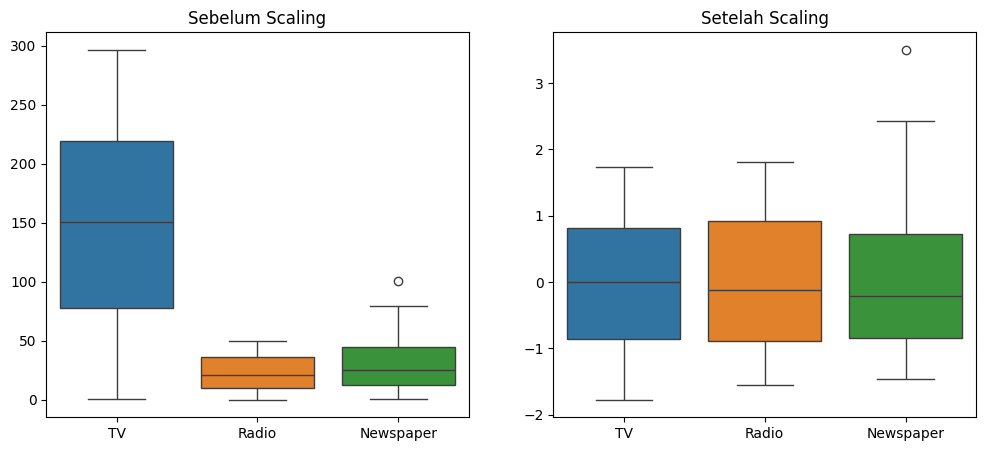

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Menggambar boxplot untuk data X_train belum di-scaling.
sns.boxplot(data=X_train[['TV', 'Radio', 'Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Menggambar boxplot untuk data X_train sudah di-scaling.
sns.boxplot(data=X_train_scaled_df[['TV', 'Radio', 'Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")

plt.show()

In [ ]:
# melatih model tanpa regularization
lr = LinearRegression()

# latih model menggungakan data scaling
lr.fit(X_train_scaled, y_train)

# Melakukan prediksi terhadap data latih (train) dan data uji (test)
y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

# Hitung RMSE untuk melihat tingkat error prediksi
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

# Menampilkan hasil evaluasi dan bobot koefisien masing-masing fitur (TV, Radio, Newspaper)
print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [ ]:
# Pelatihan model dengan L2 Regularization (Ridge Regression)
# Parameter alpha=1.0 sebagai nilai lambda (λ). Semakin besar nilainya, semakin kuat penaltinya.
ridge = Ridge(alpha=1.0)

# Latih model mengguanakan data yang di scaling
ridge.fit(X_train_scaled, y_train)

# Pediksi terhadap data latih dan data uji
y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

# Hitung RMSE untuk mengevaluasi performa model Ridge
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

# Menampilkan hasil evaluasi dan melihat perubahan bobot koefisien
# Nilainya pasti akan mengecil dibandingkan model Linear Regression murni, tapi tidak ada yang benar-benar 0.
print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [ ]:
# Pelatihan model dengan L1 Regularization (Lasso Regression)
# Lasso menggunakan penalti nilai mutlak (absolut).
lasso = Lasso(alpha=0.1)

# Latih model mengguanakan data yang di scaling
lasso.fit(X_train_scaled, y_train)

# Prediksi terhadap data latih dan data uji
y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

# Hitung tingkat error (RMSE) untuk evaluasi performa
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

# Baris koefisien bernilai 0,0, menunjukan lasso otomatis melakukan "Feature Selection".
print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


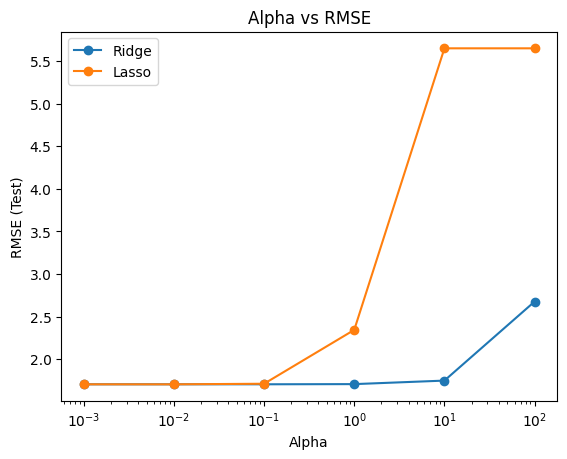

In [ ]:
# Daftar nilai lambda (alpha) yang akan diuji
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# Inisialisasi array untuk menyimpan hasil RMSE dari masing-masing model
ridge_rmse = []
lasso_rmse = []

# looping untuk setiap nilai alpha
for a in alphas:
    # Inisialisasi dan pelatihan model
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    # Hitung RMSE dari prediksi data uji, lalu simpan dalam list
    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

# Visualisasi Hasil
# Membuat plot line untuk Ridge dan Lasso
plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')

# Mengubah skala sumbu X menjadi logaritmik karena rentang nilai alpha sangat jauh (0.001 ke 100)
plt.xscale("log")

# Menambahkan label dan judul grafik agar informatif di laporan
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.legend()
plt.title("Alpha vs RMSE")

# Menampilkan grafik
plt.show()